In [ ]:
import sqlite3
import pandas as pd
conn = sqlite3.connect('sow.db')
df = pd.read_sql_query("SELECT * FROM sow WHERE id = 1", conn)
df



AttributeError: 'DataFrame' object has no attribute 'dict'

In [2]:
from neo4j import GraphDatabase
import sys

uri = "bolt://localhost:7687"
user = "neo4j"
password = "your_password" # Change this

try:
    driver = GraphDatabase.driver(uri, auth=(user, password))
    driver.verify_connectivity()
    print("Connection successful!")
    driver.close()
except Exception as e:
    print(f"Connection failed: {e}")

Connection failed: Couldn't connect to localhost:7687 (resolved to ('[::1]:7687', '127.0.0.1:7687')):
Failed to establish connection to ResolvedIPv6Address(('::1', 7687, 0, 0)) (reason [WinError 10061] No connection could be made because the target machine actively refused it)
Failed to establish connection to ResolvedIPv4Address(('127.0.0.1', 7687)) (reason [WinError 10061] No connection could be made because the target machine actively refused it)


In [ ]:
import sqlite3

In [1]:
from langgraph.graph import StateGraph, END
from state import AgentState
from nodes import *

workflow = StateGraph(AgentState)

workflow.add_node("detect", detect_intent)
workflow.add_node("extract", extract_update)
workflow.add_node("reconcile", reconcile_node)
workflow.add_node("update_graph", update_graph_node)
workflow.add_node("query_graph", query_graph_node)
workflow.add_node("search_vector", search_vector_node)
workflow.add_node("generate", generate_node)

workflow.set_entry_point("detect")

def route_after_detect(state):
    intent = state["intent"]

    if intent == "update":
        return "extract"
    elif intent == "query":
        return "query_graph"
    elif intent == "generate":
        return "generate"
    else:
        return "search_vector"
    

workflow.add_conditional_edges(
    "detect",
    route_after_detect,
    {
        "extract": "extract",
        "query_graph": "query_graph",
        "generate": "generate",
        "search_vector": "search_vector"
    }
)

workflow.add_edge("extract", "reconcile")
workflow.add_edge("reconcile", "update_graph")
workflow.add_edge("update_graph", END)

workflow.add_edge("query_graph", END)
workflow.add_edge("search_vector", END)
workflow.add_edge("generate", END)

app = workflow.compile()

# result = app.invoke({
#     "user_input": "Change duration to 6 months"
# })

# print(result["final_response"])

c:\Users\hahtsham\work\PR_PO\.venv\lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange
You try to use a model that was created with version 5.3.0, however, your version is 3.1.1. This might cause unexpected behavior or errors. In that case, try to update to the latest version.





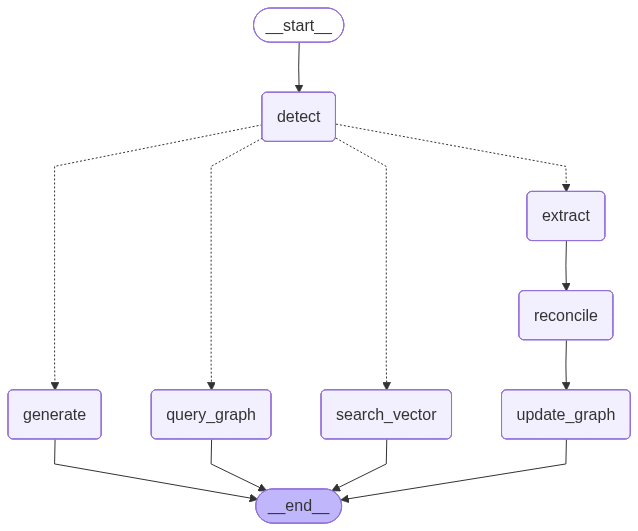

In [2]:
from IPython.display import Image, display

# Display the compiled workflow
display(Image(app.get_graph().draw_mermaid_png()))